# Econ 390 - Problem Set 9 Answers
## by M McMain
This problem set will cover Additional APIs and Aggregation. Be sure to import any packages your code needs to run and make sure the code runs without any errors.

1. [2 Points] Using the [US Treasury API](https://fiscaldata.treasury.gov/api-documentation/) and the requests package import the I Bonds Interest Rates for if you bought an I bond issued in March of 2000.
   - *Hint: Check out the "Quick API Guide" on the correct data page for more info on how to filter and format. Notice how to differentiate between the first parameter specification and the second.*
   - Ensure that it is created and read in as a csv
   - Plot how the Combined Rate changes over earning periods
   - Make sure to convert earning_period into a datetime variable
   - Label accordingly
   - Reflect on what the two massive spikes are, why they occurred, and the economic meaning of them

In [1]:
import requests
import pandas as pd
import matplotlib.pyplot as plt
from io import StringIO
import io
from datetime import datetime
import numpy as np

In [2]:
api_url = "https://api.fiscaldata.treasury.gov/services/api/fiscal_service/v1/accounting/od/i_bonds_interest_rates"
api_filter = "?filter=issue_year_month:eq:2000-03"
api_format = "&format=csv"

response = requests.get(api_url+api_filter+api_format)

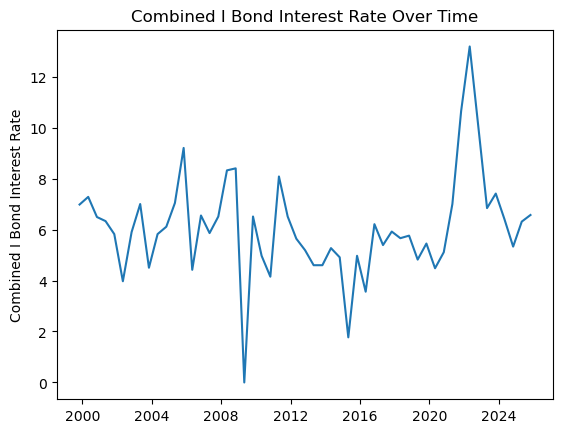

In [3]:
df_api = pd.read_csv(StringIO(response.text), parse_dates=True)

df_api["earning_period"] = pd.to_datetime(df_api["earning_period"])

fig, ax = plt.subplots()
ax.plot(df_api["earning_period"], df_api["combined_rate"])
ax.set(ylabel = "Combined I Bond Interest Rate", title = "Combined I Bond Interest Rate Over Time")

plt.show()

2. [1 Point] Use the API to get data on the Fixed Rate of I bonds over issue date from March 2000 through today
   - *Hint: You don't need all of the variables for this one. You will also need to make sure you get all of the data by setting page[size] in the link*
   - Plot how these have changed over time
   - Reflect on what the differences in the two plots represent

In [4]:
api_url = "https://api.fiscaldata.treasury.gov/services/api/fiscal_service/v1/accounting/od/i_bonds_interest_rates"
api_fields = "?fields=issue_year_month,fixed_rate"
api_filter = "&filter=issue_year_month:gt:2000-03"
api_format = "&format=csv"
api_pagination = "&page[size]=1000"

response = requests.get(api_url+api_fields+api_filter+api_format+api_pagination)

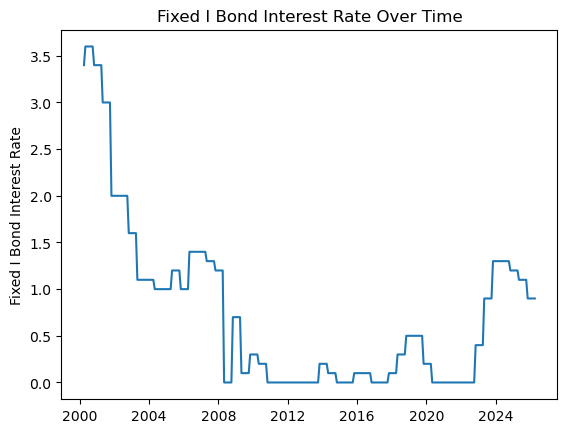

In [5]:
df_api = pd.read_csv(StringIO(response.text))

df_api["issue_year_month"] = pd.to_datetime(df_api["issue_year_month"])

fig, ax = plt.subplots()
ax.plot(df_api["issue_year_month"], df_api["fixed_rate"])
ax.set(ylabel = "Fixed I Bond Interest Rate", title = "Fixed I Bond Interest Rate Over Time")

plt.show()

3. [3 Points] Using the URL below save the data using the requests package. It is quarterly year-over-year growth of GDP per Person Employed from 2010 through now. Keep only the variables you need.
   - Create a variable `Region` that is "Europe" for European countries, "North America" for North American countries, and "Asia" for Asian countries
   - Create a variable `Year` that is the year of the entry.
     - *Hint: The variable for time period is `TIME_PERIOD`. You can access the year of a datetime series by using .dt.year*
   - Group by `Region` and `Year` and use `agg` to find the standard deviation and average GDP per Person Employed growth per region per year, print out the result
     - *Hint: The REF_AREA codes are standard and can be googled*
   - Plot a line graph of average GDP per Employed Person growth by region over time (yearly).

In [6]:
api_url_3 = "https://sdmx.oecd.org/public/rest/data/OECD.SDD.TPS,DSD_PDB@DF_PDB_ULC_Q,1.0/CAN+DEU+JPN+KOR+USA+GBR.Q.GDPEMP..PP..G1.S.?startPeriod=2010-Q1&dimensionAtObservation=AllDimensions&format=csvfilewithlabels"
response_3 = requests.get(api_url_3)

df_api_3 = pd.read_csv(StringIO(response_3.text))
df_api_3 = df_api_3[["REF_AREA","OBS_VALUE","TIME_PERIOD"]]

In [7]:
df_api_3["TIME_PERIOD"] = pd.to_datetime(df_api_3["TIME_PERIOD"])
df_api_3["Region"] = df_api_3["REF_AREA"]
df_api_3.loc[(df_api_3["Region"] == "USA") | (df_api_3["Region"] == "CAN"), "Region"] = "North America" 
df_api_3.loc[(df_api_3["Region"] == "DEU") | (df_api_3["Region"] == "GBR"), "Region"] = "Europe" 
df_api_3.loc[(df_api_3["Region"] == "JAP") | (df_api_3["Region"] == "KOR"), "Region"] = "Asia" 
df_api_3["Year"] = df_api_3["TIME_PERIOD"].dt.year
df_api_3.head()

C:\Users\micha\AppData\Local\Temp\ipykernel_16112\1333709556.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_api_3["TIME_PERIOD"] = pd.to_datetime(df_api_3["TIME_PERIOD"])


,REF_AREA,OBS_VALUE,TIME_PERIOD,Region,Year
0,DEU,0.328982,2025-01-01,Europe,2025
1,DEU,-0.180761,2025-04-01,Europe,2025
2,DEU,0.058342,2025-07-01,Europe,2025
3,DEU,0.350865,2025-10-01,Europe,2025
4,GBR,0.902523,2024-01-01,Europe,2024


                   OBS_VALUE          
                        mean       std
Region        Year                    
Asia          2010  1.137522  0.691171
              2011  0.073307  0.463120
              2012  0.347658  0.428419
              2013  0.391154  0.366033
              2014  0.200291  0.473121
...                      ...       ...
North America 2021  0.407919  0.788644
              2022 -0.061322  0.793814
              2023  0.019540  0.600676
              2024  0.470803  0.217782
              2025  0.017620  0.955387

[64 rows x 2 columns]


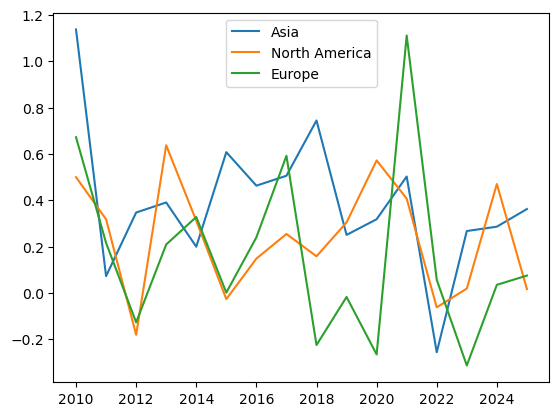

In [8]:
df_agg = df_api_3.loc[:,["OBS_VALUE","Region","Year"]].groupby(["Region","Year"]).agg(["mean", "std"])
print(df_agg)

fig, ax = plt.subplots()
ax.plot(df_agg.loc["Asia",:].index,df_agg.loc["Asia",:].loc[:,('OBS_VALUE', 'mean')],label="Asia")
ax.plot(df_agg.loc["North America",:].index,df_agg.loc["North America",:].loc[:,('OBS_VALUE', 'mean')],label="North America")
ax.plot(df_agg.loc["Europe",:].index,df_agg.loc["Europe",:].loc[:,('OBS_VALUE', 'mean')],label="Europe")
ax.legend()

## Canvas Portion:

In [45]:
import pandas as pd

url = "https://m-mcmain.github.io/files/Econ390SP26/"
variables = {"R0000100":"ID", "R0536300":"Sex", 
             "U4950200":"Educational Attainment", "U5753500":"Income", "Z9061912":"Weeks Worked"}

# Read in data
nlsy = pd.read_csv(url + "nlsy_wage_educSex.csv", na_values=-5, usecols=variables.keys(), index_col=0).rename(columns=variables)
educ_codes = {-3:"NA", 0:"None", 1:"GED", 2:"High School", 3:"Associate's", 
              4:"Bachelor's", 5:"Master's", 6:"PhD", 7:"Professional"}
nlsy["Educational Attainment"] = nlsy["Educational Attainment"].replace(educ_codes)

sex_codes = {1:"Male", 2:"Female", 0:"No Info"}
nlsy["Sex"] = nlsy["Sex"].replace(sex_codes)

nlsy_egroup = nlsy.groupby("Educational Attainment")

nlsy.loc[(nlsy["Educational Attainment"] == "High School") | (nlsy["Educational Attainment"] == "GED") | 
                 (nlsy["Educational Attainment"] == "None") | (nlsy["Educational Attainment"] == "Associate's"), 
                 "Educational Attainment"] = "Associate's or Below"
nlsy.loc[(nlsy["Educational Attainment"] == "Master's") | (nlsy["Educational Attainment"] == "PhD") |
                 (nlsy["Educational Attainment"] == "Professional"), "Educational Attainment"] = "Master's or More"
nlsy_esgroup = nlsy.groupby(["Educational Attainment", "Sex"])

egroup_agg = nlsy_egroup.agg("mean", numeric_only=True)
esgroup_agg = nlsy_esgroup.agg(["mean","std","count"])

esgroup_agg.loc[:,[("std","count")]]

KeyError: "None of [MultiIndex([('std', 'count')],\n           )] are in the [columns]"